# Telco Customer Churn Analysis

### Business Analytics Project

**Prepared by:** *Dada Oluwatomisin Rinuola*

**Program:** AnalystLab Africa Internship

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Date:** 28th June - 5th July 2026

# Project Overview

Customer churn is a critical business challenge for subscription-based companies, as retaining existing customers is often more cost-effective than acquiring new ones. This project explores a telecommunications customer dataset to identify patterns associated with customer churn and uncover factors that may influence customers' decisions to leave the company.

The analysis follows a structured exploratory data analysis (EDA) process to understand the dataset, clean the data, identify key drivers of churn, and generate business insights that can support customer retention strategies.

# Business Objective

The primary objective of this analysis is to identify the factors associated with customer churn and provide data-driven recommendations that can help improve customer retention.

Specifically, this analysis aims to:

- Understand the characteristics of the customer base.
- Explore the distribution of customer churn.
- Identify the key factors associated with customer churn.
- Generate actionable business insights and recommendations based on the findings.

# Analysis Workflow

The analysis follows these major stages:

1. Import required libraries.
2. Load the dataset.
3. Perform data inspection.
4. Clean and prepare the data.
5. Conduct exploratory data analysis (EDA).
6. Identify the key drivers of customer churn.
7. Summarize findings and provide business recommendations.

## Importing Libraries

The required python libraries are imported to support data manipulation, numerical computations and data visualizations throughout the analysis. 

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Colour palette
CHURN_RED = '#D62828'
RETAINED_GREY = '#9E9E9E'
DARK_GREY = '#333333'
ACCENT = '#1B2A4A'

PALETTE = [RETAINED_GREY, CHURN_RED]

sns.set_palette(PALETTE)

print("Setup working")

Setup working


## Loading Dataset

The dataset is loaded into a Pandas Dataframe named **telco**  to enable data exploration, cleaning, visualizations and analysis. 

In [61]:
telco = pd.read_csv("../data/raw_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Previewing the Dataset

The first 5 rows are displayed to confirm the dataset loaded successfully and to gain an initial understanding of its structure.

In [62]:
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.4 Dataset Information

We examine the structure of the dataset to determine the number of records, columns, data types and missing values.

**Finding:**

The dataset contains 7,043 customer records and 21 columns. Initial inspection shows no apparent missing values and most columns have appropriate data types. However, the `TotalCharges` column is stored as a text data type instead of a numeric type, indicating that further investigation is required before analysis. 

In [63]:
telco.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 1.5 Column Names

We review the column names to verify they imported correctly and identify any naming inconsistencies that may require standardization.

**Finding:**

The dataset contains clear and descriptive column names. Although the naming convention is not fully consistent with Python's snake_case style, the column names are readable and require no changes for this analysis.

In [64]:
telco.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### 1.6 Descriptive Statistics

We summarize the numerical variables to understand their distribution and spread, and to identify potential anomalies before further analysis.

**Finding:**

Only three columns are treated as numeric: `SeniorCitizen`, `tenure` and `MonthlyCharges`. `TotalCharges` is missing from this summary because it is currently stored as text. `SeniorCitizen` appears numeric but is actually a binary flag stored as 0 and 1 rather than Yes/No, so its mean should be read as the proportion of senior citizens rather than an average value.

In [65]:
telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Task 2: Data Cleaning

In this section we clean the dataset by handling missing values, correcting data types and validating the data. Every action taken is documented with the reason.

### 2.1 Inspect TotalCharges

The `TotalCharges` column was identified as having a text data type instead of a numeric one. We examine its values to identify what is preventing it from being stored as a number.

**Finding:**

The most frequent value in the column is a blank space rather than a number. These blanks are what force the column to be stored as text.

In [66]:
print("=" * 50)
print("TOP VALUES IN TotalCharges")
print("=" * 50)

print(telco["TotalCharges"].value_counts().head())

blanks = (telco["TotalCharges"] == " ").sum()
print("-" * 50)
print(f"Blank entries: {blanks}")

TOP VALUES IN TotalCharges
TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
Name: count, dtype: int64
--------------------------------------------------
Blank entries: 11


### 2.2 Replace blanks with NaN

The blank entries are replaced with `NaN` so that pandas recognises them as missing values rather than as text content. This is required before the column can be converted to a numeric type.

In [67]:
before = (telco["TotalCharges"] == " ").sum()

telco["TotalCharges"] = telco["TotalCharges"].replace(" ", np.nan)

after = telco["TotalCharges"].isna().sum()

print(f"Blank entries found: {before}")
print(f"Converted to NaN: {after}")

Blank entries found: 11
Converted to NaN: 11


### 2.3 Convert TotalCharges to numeric

With the blanks now recorded as `NaN`, the column can be converted to a numeric data type so it can be used in calculations and statistical analysis.

In [68]:
before_dtype = telco["TotalCharges"].dtype

telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"])

after_dtype = telco["TotalCharges"].dtype

print(f"Data type before conversion:  {before_dtype}")
print(f"Data type after conversion:   {after_dtype}")

Data type before conversion:  str
Data type after conversion:   float64


### 2.4 Verify data types

We confirm that the conversion was successful and check how many missing values now exist in the dataset.

**Finding:**

`TotalCharges` is now stored as a numeric type with 7,032 non-null values, confirming that 11 rows contain missing values.

In [69]:
telco.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 2.5 Investigate the missing rows

Before deciding how to handle the 11 missing values, we examine the affected rows to understand why the data is missing.

**Finding:**

Every row with a missing `TotalCharges` value has a `tenure` of 0. These are customers who signed up but had not yet been billed at the time the data was collected, which is why no total charge exists. The missing values are therefore explained by the customer lifecycle rather than by a data quality error.

In [70]:
missing_rows = telco[telco["TotalCharges"].isnull()]

print("=" * 50)
print("ROWS WITH MISSING TotalCharges")
print("=" * 50)

print(f"Rows affected:        {len(missing_rows)}")
print(f"Unique tenure values: {missing_rows['tenure'].unique()}")
print("-" * 50)

missing_rows

ROWS WITH MISSING TotalCharges
Rows affected:        11
Unique tenure values: [0]
--------------------------------------------------


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


### 2.6 Remove the missing rows

These 11 customers have not yet been billed and therefore have no meaningful `TotalCharges` value. They represent 0.16% of the dataset, and since we cannot estimate a total charge for a customer who has not been charged, removing them is the cleanest approach.

In [71]:
before_rows = len(telco)

telco = telco.dropna(subset="TotalCharges")

after_rows = len(telco)

print(f"Rows before cleaning:  {before_rows:,}")
print(f"Rows removed:          {before_rows - after_rows}")
print(f"Rows after cleaning:   {after_rows:,}")

Rows before cleaning:  7,043
Rows removed:          11
Rows after cleaning:   7,032


### 2.7 Final verification

We confirm that the dataset is now complete with no missing values and correct data types across all columns.

**Finding:**

The dataset now contains 7,032 records with no missing values. All columns have appropriate data types and the dataset is ready for analysis.

In [72]:
telco.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

### 2.8 Check for duplicates

We check for duplicate records to ensure each row represents a unique customer.

**Finding:**

No duplicate records were found. Each row represents a distinct customer.

In [73]:
duplicates = telco.duplicated().sum()
unique_ids = telco["customerID"].nunique()

print(f"Duplicate rows:        {duplicates}")
print(f"Unique customer IDs:   {unique_ids:,}")
print(f"Total records:         {len(telco):,}")

Duplicate rows:        0
Unique customer IDs:   7,032
Total records:         7,032


## Task 3: Exploratory Data Analysis

In this section we explore the cleaned dataset to identify patterns associated with customer churn, examining how churn varies across contract types, services, payment methods and customer tenure.

### 3.1 Overall churn rate

We establish the baseline churn rate to understand the scale of the problem before examining individual factors.

**Finding:**

Of 7,032 customers, 26.58% churned while 73.42% were retained. Churn is therefore a minority outcome, which means any factor associated with churn rates well above 26.58% represents a meaningfully elevated risk.

In [74]:
churn_counts = telco["Churn"].value_counts()
churn_pct = telco["Churn"].value_counts(normalize=True) * 100

print("=" * 50)
print("CHURN DISTRIBUTION")
print("=" * 50)

for label in churn_counts.index:
    print(f"{label:<10} {churn_counts[label]:>8,}  ({churn_pct[label]:.2f}%)")

print("-" * 50)
print(f"{'Total':<10} {len(telco):>8,}")

CHURN DISTRIBUTION
No            5,163  (73.42%)
Yes           1,869  (26.58%)
--------------------------------------------------
Total         7,032


#### 3.1.1 Visualising churn distribution

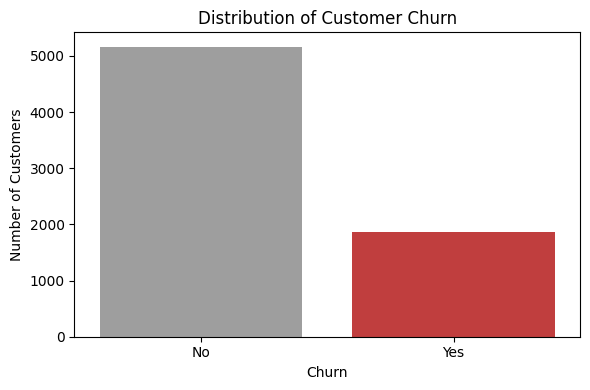

In [75]:
plt.figure(figsize=(6, 4))

sns.countplot(data=telco, x="Churn", hue="Churn", palette=PALETTE, legend=False)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "../visualizations/customer_churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3.2 Churn by contract type

We examine how churn varies across contract types to determine whether contract length is associated with customer retention.

**Finding:**

Customers on month-to-month contracts churn at 42.7%, compared to 11.3% on one-year and 2.8% on two-year contracts. Month-to-month churn is more than fifteen times the two-year rate and well above the 26.58% baseline, making contract length the strongest single predictor of churn in this dataset.

In [76]:
contract_churn = (pd.crosstab(telco["Contract"], telco["Churn"], normalize="index") * 100).round(2)

print("=" * 50)
print("CHURN RATE BY CONTRACT TYPE (%)")
print("=" * 50)

print(contract_churn)

CHURN RATE BY CONTRACT TYPE (%)
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


#### 3.2.1 Visualising churn by contract type

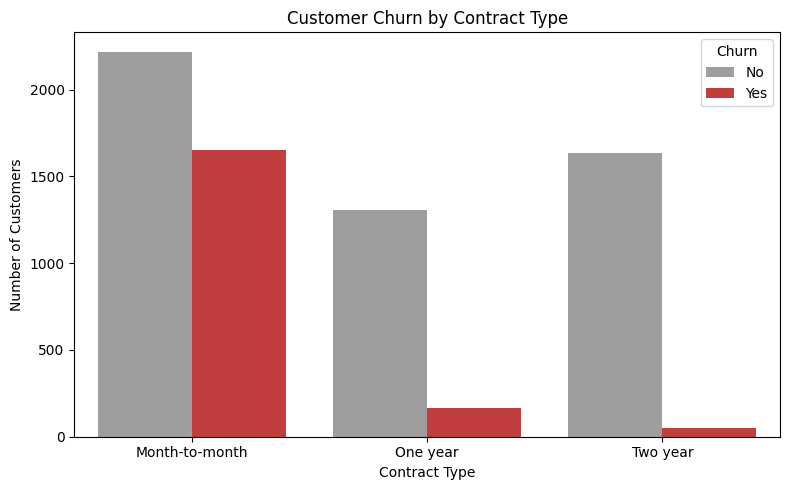

In [77]:
plt.figure(figsize=(8, 5))

sns.countplot(data=telco, x="Contract", hue="Churn", palette=PALETTE)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "../visualizations/customer_churn_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3.3 Tenure and churn

We compare how long churned and retained customers stayed with the company to determine when churn risk is highest.

**Finding:**

Churned customers have a median tenure of 10 months compared to 38 months for retained customers. The interquartile range for churned customers sits between 2 and 29 months, meaning most churn occurs within the first two years and a substantial share within the first few months. Although some long-tenure customers do churn, they appear as outliers rather than the norm. This suggests retention efforts are most valuable early in the customer relationship.


In [78]:
tenure_summary = telco.groupby("Churn")["tenure"].describe().round(2)

print("=" * 60)
print("TENURE BY CHURN STATUS (MONTHS)")
print("=" * 60)

print(tenure_summary[["count", "mean", "25%", "50%", "75%", "max"]])

TENURE BY CHURN STATUS (MONTHS)
        count   mean   25%   50%   75%   max
Churn                                       
No     5163.0  37.65  15.0  38.0  61.0  72.0
Yes    1869.0  17.98   2.0  10.0  29.0  72.0


#### 3.3.1 Visualising tenure by churn status

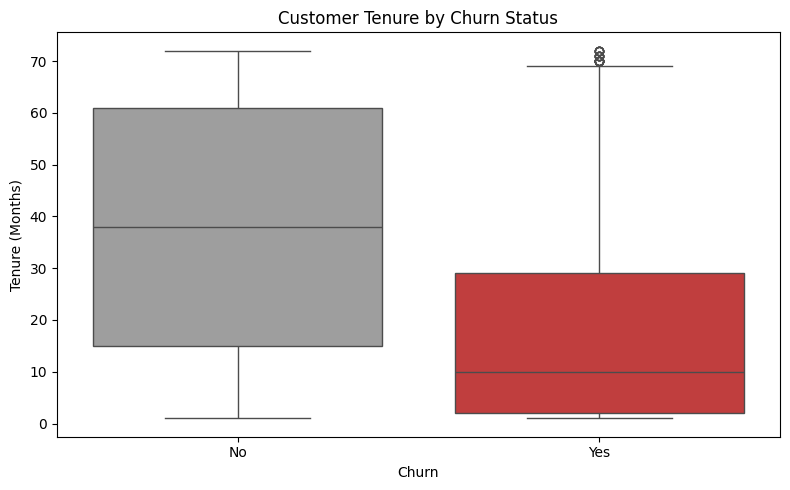

In [79]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=telco, x="Churn", y="tenure", hue="Churn", palette=PALETTE, legend=False)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.tight_layout()

plt.savefig(
    "../visualizations/tenure_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3.4 Monthly charges and churn

We compare monthly charges between churned and retained customers to determine whether price is associated with churn.

**Finding:**

Churned customers pay noticeably more per month, with a median of $79.65 against $64.45 for retained customers and a mean of $74.44 against $61.31. The difference is sharpest at the lower end: a quarter of retained customers pay under $25.10, while the equivalent figure for churned customers is $56.15. This suggests that low-cost customers rarely leave, and that churn concentrates among higher-paying customers who may be more sensitive to whether they feel the service justifies its price.

In [80]:
charges_summary = telco.groupby("Churn")["MonthlyCharges"].describe().round(2)

print("=" * 60)
print("MONTHLY CHARGES BY CHURN STATUS ($)")
print("=" * 60)

print(charges_summary[["count", "mean", "25%", "50%", "75%", "max"]])

MONTHLY CHARGES BY CHURN STATUS ($)
        count   mean    25%    50%    75%     max
Churn                                            
No     5163.0  61.31  25.10  64.45  88.48  118.75
Yes    1869.0  74.44  56.15  79.65  94.20  118.35


#### 3.4.1 Visualising monthly charges by churn status

**Note:** Each curve shows the distribution within its own group rather than raw customer counts, so the two curves are scaled independently.

**Finding:**

The retained group has a sharp peak around $20 per month that is almost entirely absent from the churned group, showing the concentration of low-cost customers is not just lower among churners but nearly non-existent.

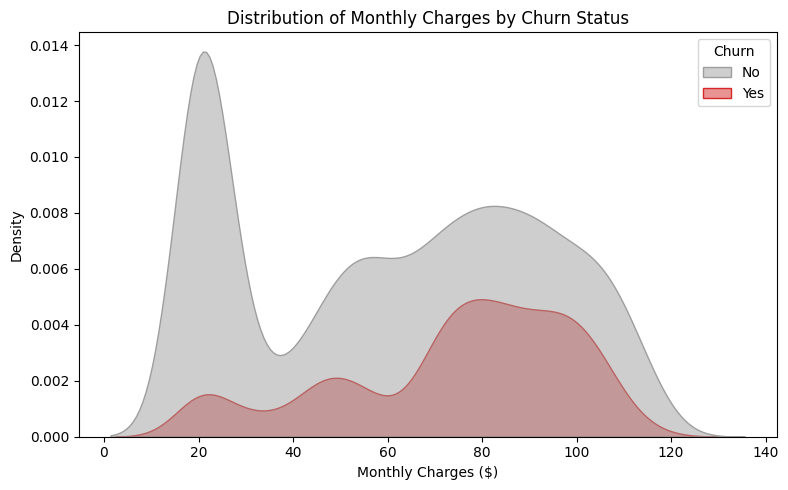

In [81]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=telco, x="MonthlyCharges", hue="Churn", palette=PALETTE, fill=True, alpha=0.5)
plt.title("Distribution of Monthly Charges by Churn Status")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

### 3.5 Churn by internet service

We examine how churn varies across internet service types to determine whether the service a customer subscribes to is associated with retention.

**Finding:**

Fibre optic customers churn at 41.89%, more than double the 19.00% seen among DSL customers and well above the 26.58% baseline. Customers with no internet service churn least at just 7.43%. Since fibre optic is also the most expensive service tier, this pattern overlaps with the earlier finding on monthly charges, and the two factors cannot be separated from one another in this analysis.

In [82]:
internet_churn = (pd.crosstab(
    telco["InternetService"],
    telco["Churn"],
    normalize="index"
) * 100).round(2)

print("=" * 50)
print("CHURN RATE BY INTERNET SERVICE (%)")
print("=" * 50)

print(internet_churn)

CHURN RATE BY INTERNET SERVICE (%)
Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


#### 3.5.1 Visualizing churn by internet service

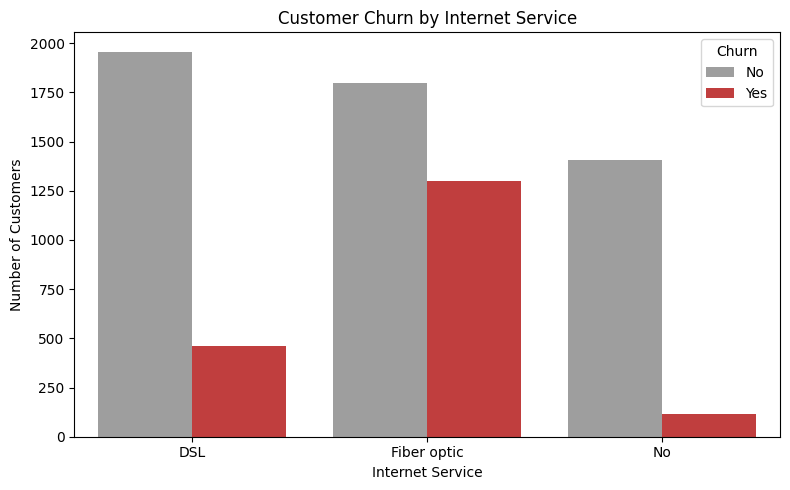

In [83]:
plt.figure(figsize=(8, 5))

sns.countplot(data=telco, x="InternetService", hue="Churn", palette=PALETTE)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "../visualizations/customer_churn_by_internet.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3.6 Churn by payment method

We examine how churn varies across payment methods to determine whether the way customers pay is associated with retention.

**Finding:**

Customers paying by electronic check churn at 45.29%, far above every other method and well above the 26.58% baseline. The two automatic methods show the lowest churn, at 16.73% for bank transfer and 15.25% for credit card, while mailed cheque sits at 19.20%. The pattern suggests that customers on automatic payments are substantially more likely to stay, though it is unclear whether the payment method itself matters or whether it reflects a different type of customer.

In [84]:
payment_churn = (pd.crosstab(
    telco["PaymentMethod"],
    telco["Churn"],
    normalize="index"
) * 100).round(2)

print("=" * 60)
print("CHURN RATE BY PAYMENT METHOD (%)")
print("=" * 60)

print(payment_churn)

CHURN RATE BY PAYMENT METHOD (%)
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.27  16.73
Credit card (automatic)    84.75  15.25
Electronic check           54.71  45.29
Mailed check               80.80  19.20


#### 3.6.1 Visualizing churn by payment method

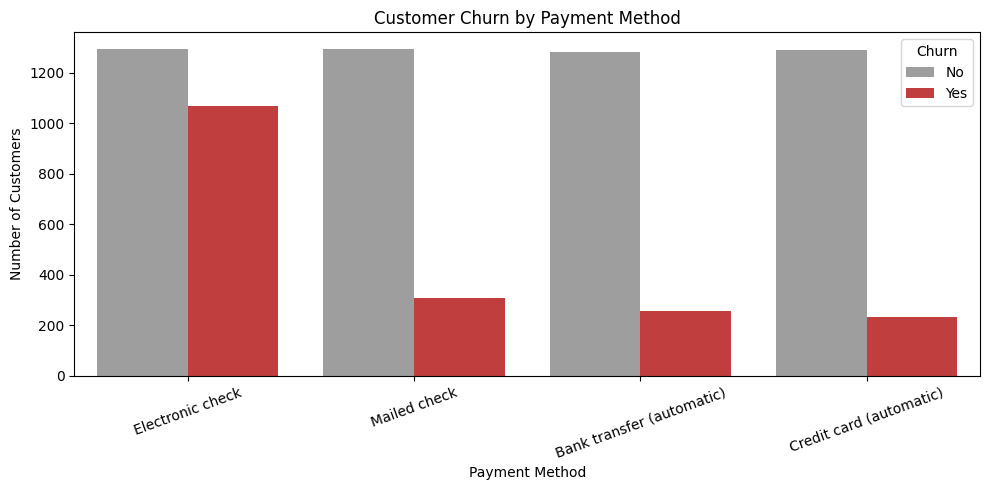

In [85]:
plt.figure(figsize=(10, 5))

sns.countplot(data=telco, x="PaymentMethod", hue="Churn", palette=PALETTE)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../visualizations/customer_churn_by_payment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3.7 Churn by online security

We examine whether subscribing to online security is associated with customer retention.

**Finding:**

Customers without online security churn at 41.78%, compared to 14.64% for those who subscribe to it — nearly three times the rate. Customers with no internet service at all show the lowest churn at 7.43%, though this group is not directly comparable since online security is not available to them. The pattern suggests that customers with add-on services are more embedded in the product and less likely to leave.

In [86]:
security_churn = (pd.crosstab(
    telco["OnlineSecurity"],
    telco["Churn"],
    normalize="index"
) * 100).round(2)

print("=" * 55)
print("CHURN RATE BY ONLINE SECURITY (%)")
print("=" * 55)

print(security_churn)

CHURN RATE BY ONLINE SECURITY (%)
Churn                   No    Yes
OnlineSecurity                   
No                   58.22  41.78
No internet service  92.57   7.43
Yes                  85.36  14.64


#### 3.7.1 Visualizing churn by online security

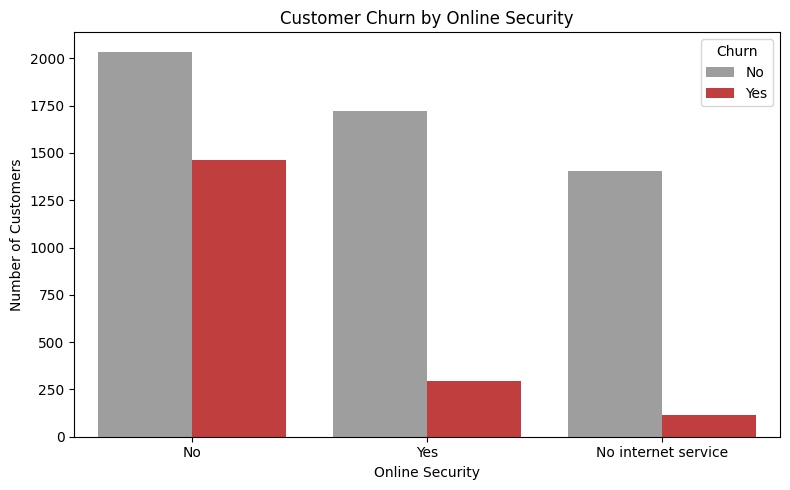

In [87]:
plt.figure(figsize=(8, 5))

sns.countplot(data=telco, x="OnlineSecurity", hue="Churn", palette=PALETTE)

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "../visualizations/customer_churn_by_security.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3.8 Export cleaned dataset

The cleaned dataset is saved so it can be used for dashboard development in Power BI without repeating the cleaning steps.

In [88]:
telco.to_csv("../data/cleaned_data/telco_churn_cleaned.csv", index=False)

print(f"Cleaned dataset exported: {telco.shape[0]:,} rows, {telco.shape[1]} columns")

Cleaned dataset exported: 7,032 rows, 21 columns


## Task 4: Insights and Recommendations

### 4.1 Summary of findings

Of 7,032 customers, 26.58% churned. Five factors showed a clear association with churn:

**Contract type** — Month-to-month customers churned at 42.71%, against 11.28% on one-year and 2.85% on two-year contracts. This is the strongest single pattern in the dataset.

**Tenure** — Churned customers had a median tenure of 10 months compared to 38 months for retained customers, and a quarter left within 2 months. Churn concentrates heavily in the early stages of the customer relationship.

**Internet service** — Fibre optic subscribers churned at 41.89%, more than double the 19.00% among DSL customers.

**Online security** — Customers without online security churned at 41.78%, nearly three times the 14.64% among subscribers.

**Payment method** — Electronic cheque users churned at 45.29%, compared to 15.25% and 16.73% for the two automatic payment methods.

Monthly charges were also higher among churned customers, with a median of $79.65 against $64.45. However, this overlaps with internet service type, as fibre optic is the most expensive tier, so price and service quality cannot be separated in this analysis.

### 4.2 Recommendations

1. **Incentivise longer contracts.** Offer discounts or loyalty benefits for customers moving from month-to-month to one- or two-year terms.

2. **Focus retention on the first year.** Since half of all churn occurs within the first 10 months, early-tenure customers should be prioritised for engagement and support.

3. **Investigate the fibre optic experience.** The churn rate among fibre subscribers warrants a review of service quality, pricing, and customer expectations for this tier.

4. **Bundle online security.** Including it in internet packages rather than selling it separately may improve retention, given the substantial difference in churn rates.

5. **Encourage automatic payment methods.** Customers on electronic cheque churn at nearly three times the rate of those on automatic payments.

### 4.3 Limitations

This analysis identifies associations, not causes. Several factors overlap — fibre optic customers pay more and are more likely to use electronic cheque — so the individual contribution of each factor cannot be isolated without further modelling.